# import and load all

In [1]:
%load_ext autoreload
%autoreload all

In [2]:
import torch

import numpy as np
import polars as pl
from tqdm import tqdm
import torch.nn.functional as F

from functions.utils import load_config, get_tensor_from_numpy
config = load_config() 
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
cpt_label_ref_embs = np.load(config["EMBEDDING_CONCEPT"]["cpt_snomed_ref_emb"])
df_map_ref = pl.read_parquet(config["EMBEDDING_CONCEPT"]["cpt_snomed_ref_info"])

cpt_label_ehrshot_embs = np.load(config["EMBEDDING_CONCEPT"]["cpt_ehrshot_emb"])
df_concept_ehrshot = pl.read_parquet(config["EMBEDDING_CONCEPT"]["cpt_ehrshot_info"])


In [4]:
cpt_label_ref_embs = get_tensor_from_numpy(cpt_label_ref_embs, device)
cpt_label_ehrshot_embs = get_tensor_from_numpy(cpt_label_ehrshot_embs, device)

emb_c = F.normalize(cpt_label_ref_embs, dim=1)
emb_q = F.normalize(cpt_label_ehrshot_embs, dim=1)

In [5]:
# map concepts by cosine similarity
rows = []
for i in tqdm(range(emb_q.shape[0])):
    sim = emb_q[i,:] @ emb_c.T
    sim_score, sim_index = sim.max(dim=0)
    rows.append(
        {
            "ehrshot_concept_id": df_concept_ehrshot[i]["code_value"][0],
            "ehrshot_label": df_concept_ehrshot[i]["label"][0],
            "ref_concept_id": df_map_ref[sim_index.item()]["id"][0],
            "ref_label": df_map_ref[sim_index.item()]["label"][0],
            "similarity_score": sim_score.item(),
        }
    )
df_mapping = pl.DataFrame(rows)

100%|██████████| 30759/30759 [08:24<00:00, 60.92it/s]


In [ ]:

# df_mapping.join(df_concept_ehrshot.select("code_value", "bool_map_direct", "count"), left_on= "ref_concept_id", right_on="code_value", how="left")
df_concept_mappped = (df_concept_ehrshot.select("code_value", "bool_map_direct", "code_type", "count")
    .join(df_mapping, left_on="code_value", right_on="ehrshot_concept_id")
    .unique()
    .rename({
        "code_value": "ehrshot_concept_id",
        "bool_map_direct": "exact_to_snomed",
        "code_type": "ehrshot_concept_original_ontology",
        "count": "frequency",
        "ref_concept_id": "best_matched_snomed_concept_id",
        "ref_label": "best_matched_snomed_label",
    })
    .select([
        "exact_to_snomed",
        "ehrshot_concept_id",
        "ehrshot_concept_original_ontology",
        "ehrshot_label",
        "frequency",
        "best_matched_snomed_concept_id",
        "best_matched_snomed_label",
        "similarity_score"
        ]
    ))
df_concept_mappped.write_parquet(config["vocab_data"]["path"] + config["vocab_data"]["mapping"])

df_concept_mappped.write_excel("temp/mapping_concept_ehrshot_to_snomedct.xlsx")


# analysis

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
df_concept_mappped = pl.read_parquet(config["vocab_data"]["path"] + config["vocab_data"]["mapping"]).with_columns(data_volume_per = pl.col("frequency") / pl.col("frequency").sum())
# df_concept_mappped_approx = df_concept_mappped.filter(pl.col("exact_to_snomed") == False)

In [ ]:
# data volume percentage by mapping status
df_concept_mappped.group_by("exact_to_snomed").agg(pl.sum("data_volume_per")*100)

exact_to_snomed,data_volume_per
bool,f64
false,92.456256
true,7.543744


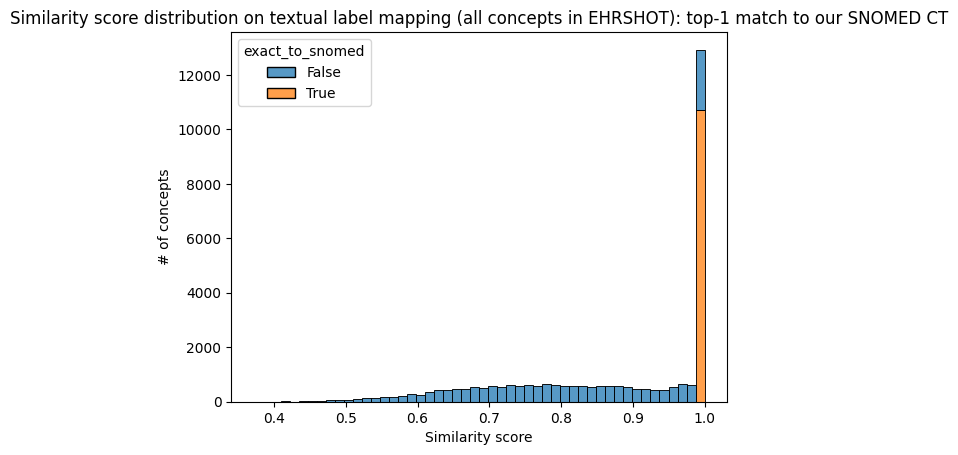

In [78]:
# Convert Polars → Pandas (Seaborn expects pandas-like input)
df_pd = df_concept_mappped.select(
    ["similarity_score", "exact_to_snomed"]
).to_pandas()

sns.histplot(
    data=df_pd,
    x="similarity_score",
    hue="exact_to_snomed",
    bins=50,
    multiple="stack"
)

plt.xlabel("Similarity score")
plt.ylabel("# of concepts")
plt.title("Similarity score distribution on textual label mapping (all concepts in EHRSHOT): top-1 match to our SNOMED CT")
plt.show()

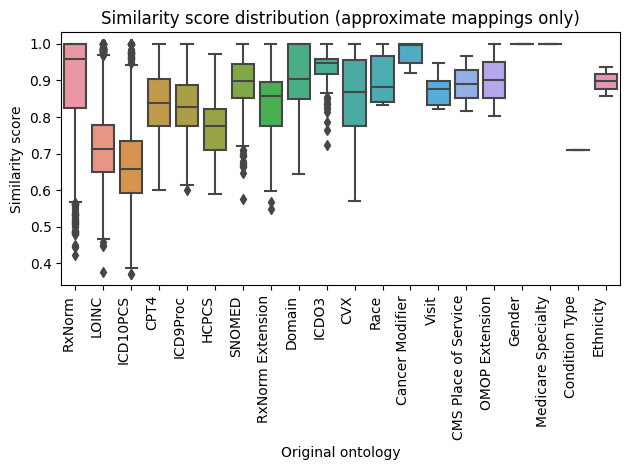

In [45]:
# Filter (Polars)
df_concept_mappped_approx = df_concept_mappped.filter(
    pl.col("exact_to_snomed") == False
)

# Convert to pandas for seaborn
df_pd = df_concept_mappped_approx.select(
    ["ehrshot_concept_original_ontology", "similarity_score"]
).to_pandas()

sns.boxplot(
    data=df_pd,
    x="ehrshot_concept_original_ontology",
    y="similarity_score"
)

plt.xticks(rotation=90, ha="right")
plt.xlabel("Original ontology")
plt.ylabel("Similarity score")
plt.title("Similarity score distribution (approximate mappings only)")
plt.tight_layout()
plt.show()

In [83]:
thresholds = []
data_volume_percents_total = []
number_of_concepts = []
number_of_concepts_check_needed = []
number_of_concepts_check_needed_less_1 = []



for thres in np.arange(0.3, 1.02, 0.01):
    df_concept_mappped_temp = df_concept_mappped.filter(pl.col('similarity_score') >= thres)
    data_volume_percents_total.append(df_concept_mappped_temp.select(pl.sum("data_volume_per")).to_numpy().flatten()[0]*100)
    number_of_concepts.append(df_concept_mappped_temp.height)
    thresholds.append(thres)
    number_of_concepts_check_needed.append(len(df_concept_mappped_temp.filter(pl.col("exact_to_snomed") == False)))
    number_of_concepts_check_needed_less_1.append(len(df_concept_mappped_temp.filter(pl.col("similarity_score") < 0.999)))
df_thresholds = pl.DataFrame({
    "threshold": thresholds,
    "data_volume_percents_total": data_volume_percents_total,
    "number_of_concepts": number_of_concepts,
    "number_of_concepts_check_needed": number_of_concepts_check_needed,
    "number_of_concepts_check_needed_less_1": number_of_concepts_check_needed_less_1
})
df_thresholds

threshold,data_volume_percents_total,number_of_concepts,number_of_concepts_check_needed,number_of_concepts_check_needed_less_1
f64,f64,i64,i64,i64
0.3,100.0,30774,20081,18353
0.31,100.0,30774,20081,18353
0.32,100.0,30774,20081,18353
0.33,100.0,30774,20081,18353
0.34,100.0,30774,20081,18353
…,…,…,…,…
0.97,42.303768,13772,3079,1351
0.98,40.517503,13279,2586,858
0.99,36.678697,12805,2112,384


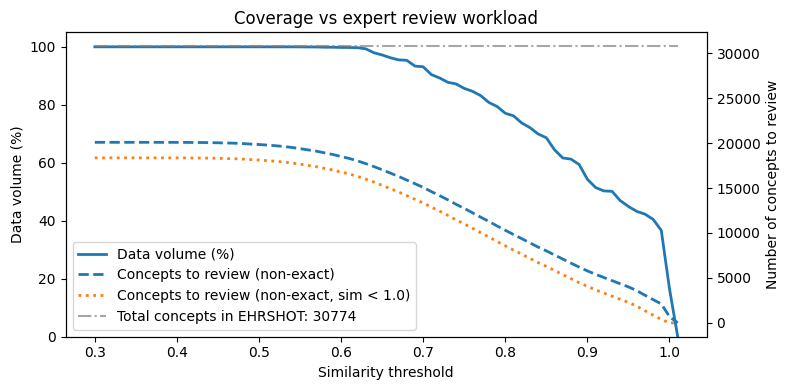

In [86]:
import matplotlib.pyplot as plt

df_pd = df_thresholds.to_pandas()

x = df_pd["threshold"].values
y_cov = df_pd["data_volume_percents_total"].values

y_review_all = df_pd["number_of_concepts_check_needed"].values
y_review_less_1 = df_pd["number_of_concepts_check_needed_less_1"].values  # your extra series

fig, ax_left = plt.subplots(figsize=(8, 4))

# -----------------------------
# Left axis: coverage (%)
# -----------------------------
(line_cov,) = ax_left.plot(
    x, y_cov,
    linewidth=2,
    label="Data volume (%)"
)
ax_left.set_xlabel("Similarity threshold")
ax_left.set_ylabel("Data volume (%)")
ax_left.set_ylim(0, 105)

# -----------------------------
# Right axis: expert workload (counts)
# -----------------------------
ax_right = ax_left.twinx()

(line_review_all,) = ax_right.plot(
    x, y_review_all,
    linewidth=2,
    linestyle="--",
    label="Concepts to review (non-exact)"
)

(line_review_less_1,) = ax_right.plot(
    x, y_review_less_1,
    linewidth=2,
    linestyle=":",
    label="Concepts to review (non-exact, sim < 1.0)"
)

ax_right.set_ylabel("Number of concepts to review")

# -----------------------------
# Reference: total concepts (right axis)
# -----------------------------
num_concept_all = df_concept_mappped.height
(hline_total,) = ax_right.plot(
    [x.min(), x.max()],
    [num_concept_all, num_concept_all],
    linestyle="-.",
    color="gray",
    alpha=0.7,
    label=f"Total concepts in EHRSHOT: {num_concept_all}"
)

# -----------------------------
# Legend: merge handles from both axes
# -----------------------------
handles = [line_cov, line_review_all, line_review_less_1, hline_total]
labels = [h.get_label() for h in handles]
ax_left.legend(handles, labels, loc="lower left")

plt.title("Coverage vs expert review workload")
plt.tight_layout()
plt.show()


In [96]:
df_thresholds.write_excel("temp/mapping_thresholds_volume_vocabsize.xlsx")#.filter(pl.col("threshold") >= 0.8)

In [98]:
df_thresholds.filter(pl.col("threshold") >= 0.80)

threshold,data_volume_percents_total,number_of_concepts,number_of_concepts_check_needed,number_of_concepts_check_needed_less_1
f64,f64,i64,i64,i64
0.8,77.081529,20996,10303,8575
0.81,76.197309,20518,9825,8097
0.82,73.726753,20064,9371,7643
0.83,72.139823,19593,8900,7172
0.84,69.943853,19122,8429,6701
…,…,…,…,…
0.97,42.303768,13772,3079,1351
0.98,40.517503,13279,2586,858
0.99,36.678697,12805,2112,384
